# U-Net Architecture

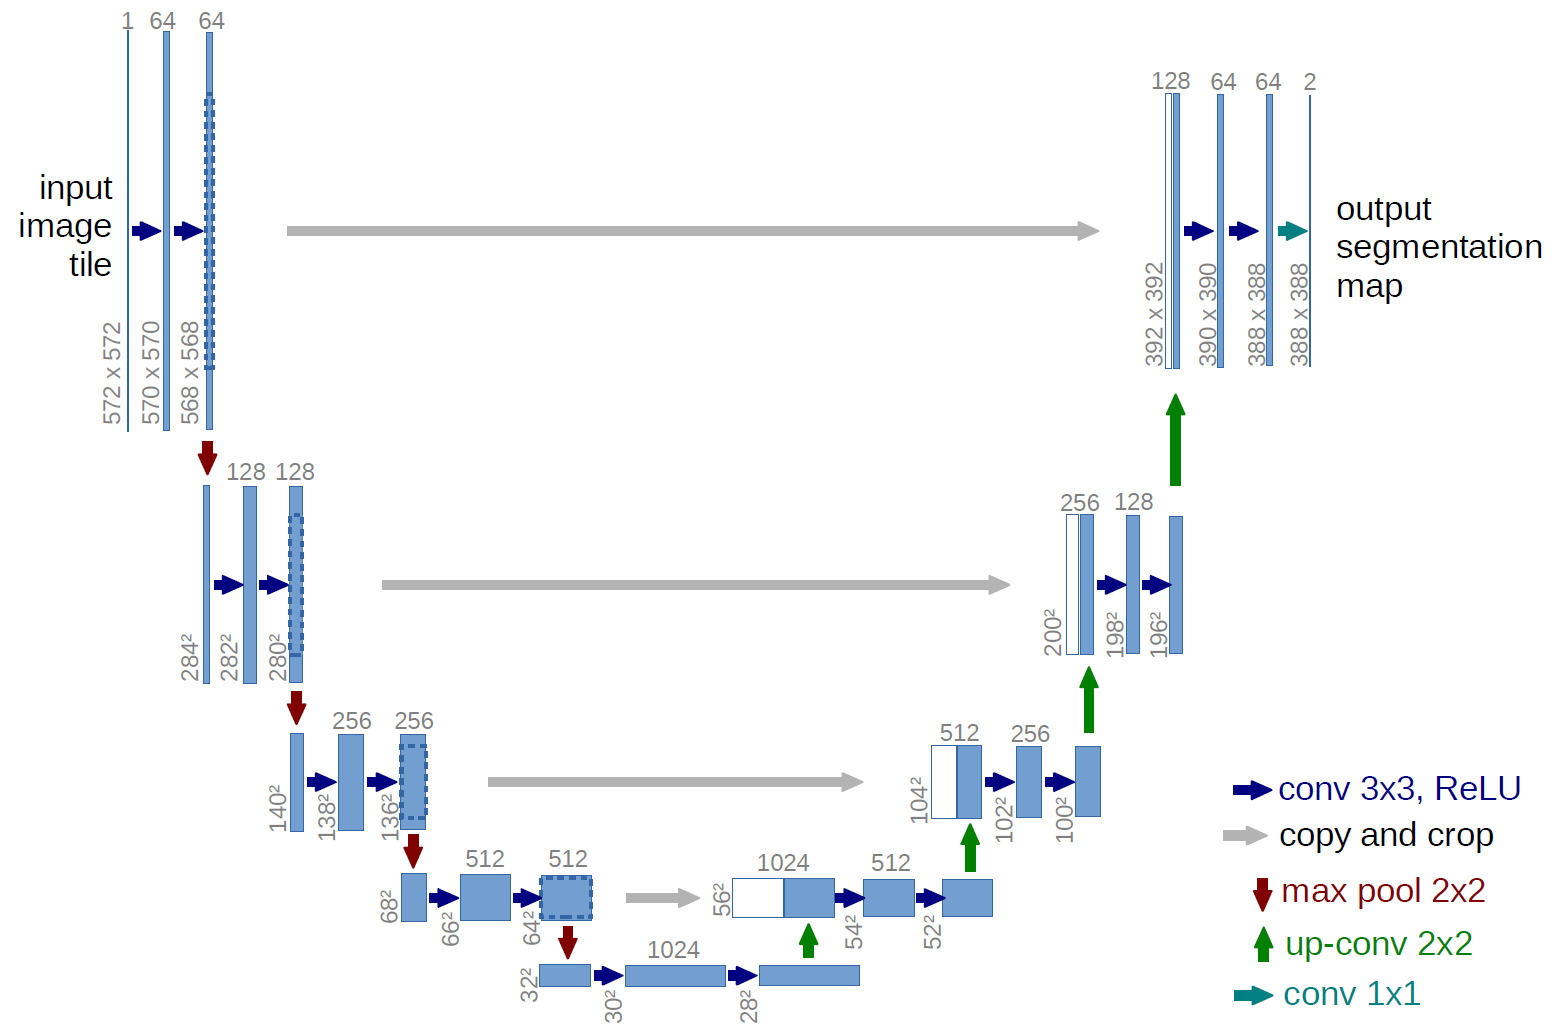

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchinfo import summary
from PIL import Image

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
torch.backends.cudnn.benchmark = True

cuda


In [3]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, stride=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [4]:
# class DownSample(nn.Module):
#     def __init__(self, in_channels, out_channels):
#         super().__init__()
#         self.conv = DoubleConv(in_channels, out_channels)
#         self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

#     def forward(self, x):
#         down = self.conv(x)
#         p = self.pool(down)

#         return down, p

In [5]:
# class UpSample(nn.Module):
#     def __init__(self, in_channels, out_channels):
#         super().__init__()
#         self.up = nn.ConvTranspose2d(in_channels, in_channels//2, kernel_size=2, stride=2)
#         self.conv = DoubleConv(in_channels, out_channels)

#     def forward(self, x1, x2):
#         x1 = self.up(x1)
#         x = torch.cat([x1, x2], 1)
#         return self.conv(x)

In [6]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, features=[64, 128, 256, 512]):
        super().__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature
        
        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature*2, feature))

        self.bottle_neck = DoubleConv(features[-1], features[-1]*2)

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottle_neck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx//2]
            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](concat_skip)

        return self.final_conv(x)            


In [7]:
from torchvision.datasets import OxfordIIITPet
import numpy as np

class PetsSeg(torch.utils.data.Dataset):
    def __init__(self, split='trainval', image_size=256):
        self.base = OxfordIIITPet(root='./data', split=split, 
                                  target_types='segmentation', download=True)
        self.image_size = image_size
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                              std=[0.229, 0.224, 0.225])

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        image, mask = self.base[idx]
        image = image.resize((self.image_size, self.image_size), Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), Image.NEAREST)
        
        image = transforms.ToTensor()(image)
        image = self.normalize(image)
        # Oxford trimap: 1=pet, 2=background, 3=border.
        mask = torch.from_numpy((np.array(mask, dtype=np.int64)-1))
        return image, mask


trainval = PetsSeg(split='trainval', image_size=256)
test = PetsSeg(split='test', image_size=256)

trainloader = torch.utils.data.DataLoader(trainval, batch_size=4, shuffle=True, pin_memory=True)
testloader = torch.utils.data.DataLoader(test, batch_size=4, shuffle=False, pin_memory=True)

In [8]:
images, masks = next(iter(trainloader))
print(torch.unique(masks))

tensor([0, 1, 2])


In [9]:
@torch.no_grad()
def mean_iou(logits, targets, num_classes):
    preds = logits.argmax(dim=1)
    ious = []

    for c in range(num_classes):
        pred_c = (preds == c)
        target_c = (targets == c)

        intersection = (pred_c & target_c).sum().item()
        union = (pred_c | target_c).sum().item()

        if union == 0:
            continue
        ious.append(intersection/union)
    return sum(ious)/len(ious) if ious else 0.0

In [10]:
model = UNet().to(device)
summary(model, input_size = (1, 3, 256, 256))

Layer (type:depth-idx)                   Output Shape              Param #
UNet                                     [1, 3, 256, 256]          --
├─ModuleList: 1-7                        --                        (recursive)
│    └─DoubleConv: 2-1                   [1, 64, 256, 256]         --
│    │    └─Sequential: 3-1              [1, 64, 256, 256]         38,848
├─MaxPool2d: 1-2                         [1, 64, 128, 128]         --
├─ModuleList: 1-7                        --                        (recursive)
│    └─DoubleConv: 2-2                   [1, 128, 128, 128]        --
│    │    └─Sequential: 3-2              [1, 128, 128, 128]        221,696
├─MaxPool2d: 1-4                         [1, 128, 64, 64]          --
├─ModuleList: 1-7                        --                        (recursive)
│    └─DoubleConv: 2-3                   [1, 256, 64, 64]          --
│    │    └─Sequential: 3-3              [1, 256, 64, 64]          885,760
├─MaxPool2d: 1-6                         [1,

In [11]:
x = torch.randn(1,3,256,256).to(device)

with torch.no_grad():
    y = model(x)

print(y.shape)

torch.Size([1, 3, 256, 256])


In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0001)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

In [13]:
total_step = len(trainloader)
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    for i, (images, masks) in enumerate(trainloader):
        images, masks = images.to(device), masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if i%50 == 0:
            iou = mean_iou(outputs, masks, 3)
            print(f"Epoch {epoch+1}/{num_epochs} | Step {i+1}/{total_step} | Loss: {loss.item():.4f} | mIoU: {iou:.4f}")
    
    scheduler.step()

Epoch 1/20 | Step 1/920 | Loss: 1.1193 | mIoU: 0.1819
Epoch 1/20 | Step 51/920 | Loss: 0.8350 | mIoU: 0.3821
Epoch 1/20 | Step 101/920 | Loss: 0.7930 | mIoU: 0.4056
Epoch 1/20 | Step 151/920 | Loss: 0.6894 | mIoU: 0.4078
Epoch 1/20 | Step 201/920 | Loss: 0.7845 | mIoU: 0.4224
Epoch 1/20 | Step 251/920 | Loss: 0.8153 | mIoU: 0.3729
Epoch 1/20 | Step 301/920 | Loss: 0.7895 | mIoU: 0.4291
Epoch 1/20 | Step 351/920 | Loss: 0.8367 | mIoU: 0.4141
Epoch 1/20 | Step 401/920 | Loss: 0.6005 | mIoU: 0.4395
Epoch 1/20 | Step 451/920 | Loss: 0.4413 | mIoU: 0.5971
Epoch 1/20 | Step 501/920 | Loss: 0.5241 | mIoU: 0.5508
Epoch 1/20 | Step 551/920 | Loss: 0.6473 | mIoU: 0.4031
Epoch 1/20 | Step 601/920 | Loss: 0.6182 | mIoU: 0.5022
Epoch 1/20 | Step 651/920 | Loss: 0.4682 | mIoU: 0.5715
Epoch 1/20 | Step 701/920 | Loss: 0.6534 | mIoU: 0.4855
Epoch 1/20 | Step 751/920 | Loss: 0.5267 | mIoU: 0.5498
Epoch 1/20 | Step 801/920 | Loss: 0.5170 | mIoU: 0.5030
Epoch 1/20 | Step 851/920 | Loss: 0.5385 | mIoU: 0.

In [14]:
model.eval()
with torch.no_grad():
    total_iou = 0
    n = 0
    for images, masks in testloader:
        images, masks = images.to(device), masks.to(device)

        outputs = model(images)

        total_iou += mean_iou(outputs, masks, 3) * images.size(0)
        n += images.size(0)
    print(f"Test mIoU = {total_iou / n:.4f}")

Test mIoU = 0.7525
